# Experiment 7: Dimensionality Reduction and Model Evaluation (With and Without PCA)

Spambase dataset, ten classifiers each trained and 5-fold cross-validated with and without PCA.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

RNG = 42
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

## Load the data

In [2]:
WORDS = ["make","address","all","3d","our","over","remove","internet","order","mail",
"receive","will","people","report","addresses","free","business","email","you","credit",
"your","font","000","money","hp","hpl","george","650","lab","labs","telnet","857","data",
"415","85","technology","1999","parts","pm","direct","cs","meeting","original","project",
"re","edu","table","conference"]
CHARS = [";","(","[","!","$","#"]
COL_NAMES = ([f"word_freq_{w}" for w in WORDS] + [f"char_freq_{c}" for c in CHARS] +
             ["capital_run_length_average","capital_run_length_longest",
              "capital_run_length_total","is_spam"])

df = pd.read_csv("spambase.data", header=None, names=COL_NAMES)
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Class distribution:\n", df["is_spam"].value_counts())

feature_names = [c for c in df.columns if c != "is_spam"]
X = df[feature_names].values
y = df["is_spam"].values

Dataset shape: (4601, 58)
Missing values: 0
Class distribution:
 is_spam
0    2788
1    1813
Name: count, dtype: int64


## Helper functions

In [3]:
def evaluate(y_true, y_pred, y_score=None):
    d = dict(accuracy=accuracy_score(y_true, y_pred),
             precision=precision_score(y_true, y_pred),
             recall=recall_score(y_true, y_pred),
             f1=f1_score(y_true, y_pred))
    if y_score is not None:
        d["roc_auc"] = roc_auc_score(y_true, y_score)
    return d

def get_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def train_and_evaluate_classifier(model, X_train, y_train, X_test, y_test):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    pred = model.predict(X_test)
    score = get_score(model, X_test)
    metrics = evaluate(y_test, pred, score)
    metrics["train_time"] = train_time
    return dict(model=model, pred=pred, score=score, metrics=metrics)

def build_eda_summary_figure(df, top_feats):
    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    axes = axes.ravel()

    sns.countplot(x=df["is_spam"], ax=axes[0])
    axes[0].set_title("Class Distribution")
    axes[0].set_xlabel("is_spam (0=ham, 1=spam)"); axes[0].set_ylabel("Count")

    for i, feat in enumerate(top_feats[:6]):
        ax = axes[1 + i]
        clip = df[feat].quantile(0.95)
        for label, color in [(0, "seagreen"), (1, "indianred")]:
            vals = df.loc[df["is_spam"] == label, feat]
            vals = vals[vals <= clip]
            sns.histplot(vals, bins=25, color=color, alpha=0.55,
                         label="ham" if label == 0 else "spam", ax=ax, kde=False)
        ax.set_title(feat, fontsize=11)
        ax.set_xlabel(feat); ax.set_ylabel("Count")
        if i == 0:
            ax.legend(fontsize=10)

    ax8 = axes[7]
    sns.heatmap(df[top_feats + ["is_spam"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
                ax=ax8, cbar=False, annot_kws={"size": 6})
    ax8.set_title("Correlation Heatmap (top 10 features)", fontsize=11)
    ax8.tick_params(axis='x', labelsize=6, rotation=90)
    ax8.tick_params(axis='y', labelsize=6)

    for i, feat in enumerate(top_feats[:3]):
        ax = axes[8 + i]
        clip = df[feat].quantile(0.95)
        sns.boxplot(x=df["is_spam"], y=df[feat].clip(upper=clip), ax=ax)
        ax.set_title(feat, fontsize=11)
        ax.set_xlabel("is_spam"); ax.set_ylabel(feat)

    ax12 = axes[11]
    for label, color in [(0, "seagreen"), (1, "indianred")]:
        sub = df[df["is_spam"] == label]
        ax12.scatter(sub[top_feats[0]], sub[top_feats[1]], s=10, alpha=0.5,
                     color=color, label="ham" if label == 0 else "spam")
    ax12.set_xlabel(top_feats[0]); ax12.set_ylabel(top_feats[1])
    ax12.set_title(f"{top_feats[0]} vs. {top_feats[1]}", fontsize=11)
    ax12.legend(fontsize=10)

    plt.tight_layout()
    return fig

## EDA

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


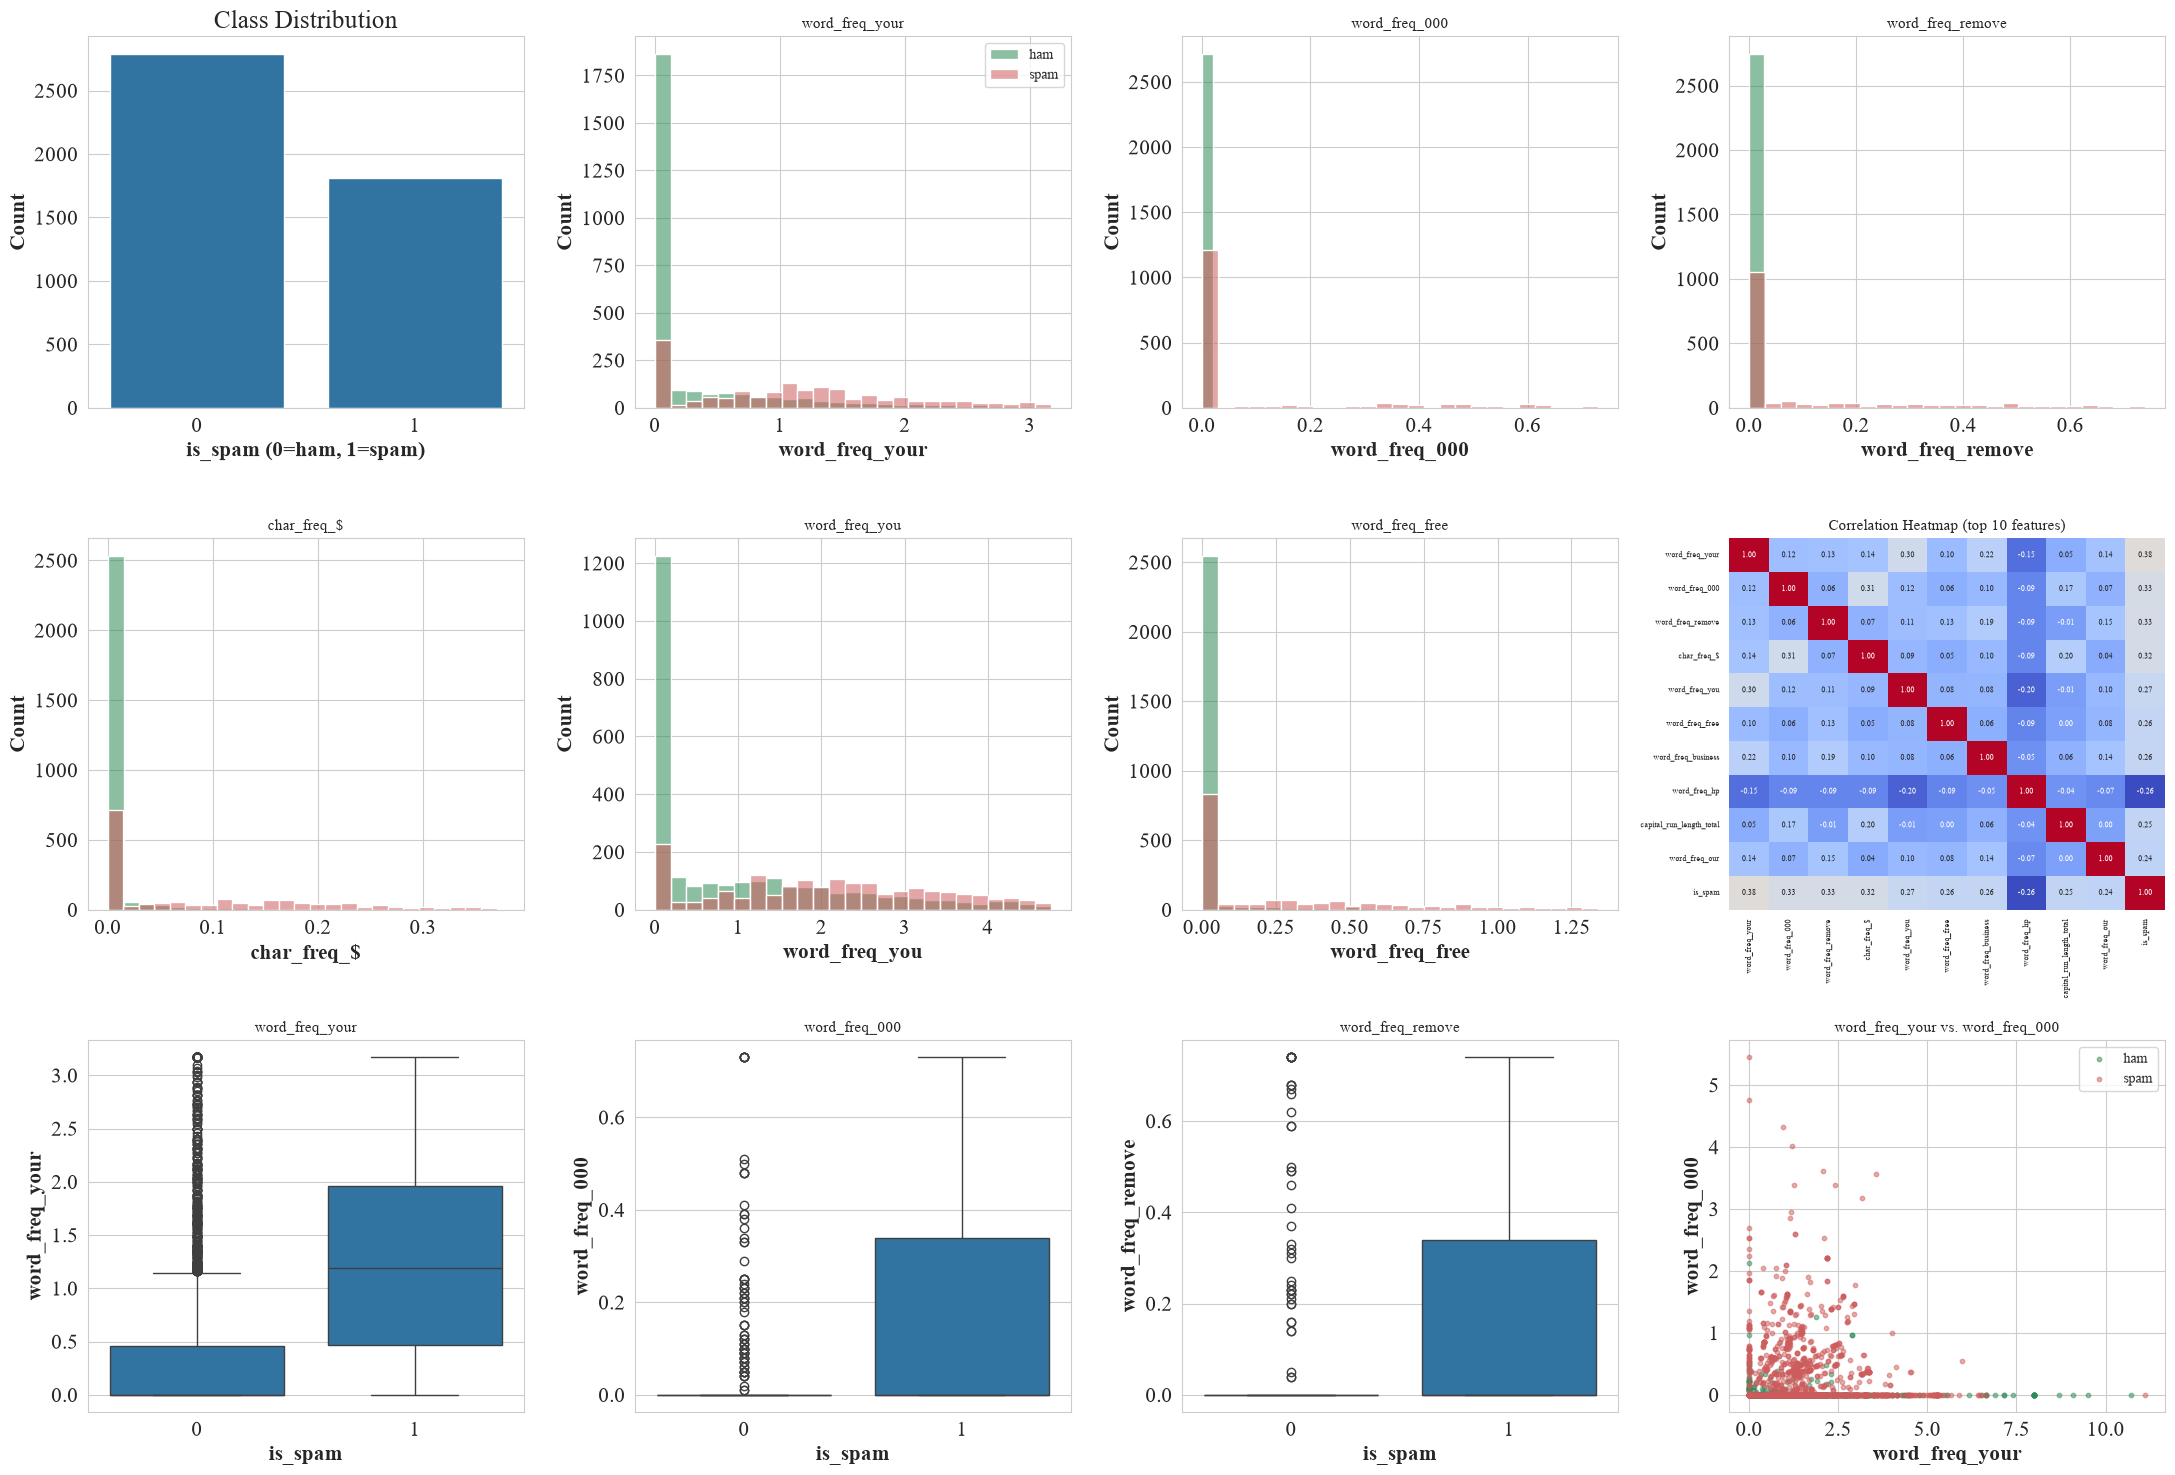

In [4]:
corr = df[feature_names + ["is_spam"]].corr()["is_spam"].drop("is_spam").abs().sort_values(ascending=False)
top_feats = corr.head(10).index.tolist()

eda_fig = build_eda_summary_figure(df, top_feats)
eda_fig.savefig("figures/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig("figures/00_eda_summary.png", dpi=150)
plt.show()
plt.close(eda_fig)

## Train/test split and scaling

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RNG)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

Train: (3680, 57), Test: (921, 57)


## PCA

Components for 95% variance: 48 of 57
Explained variance with 48 components: 0.9549


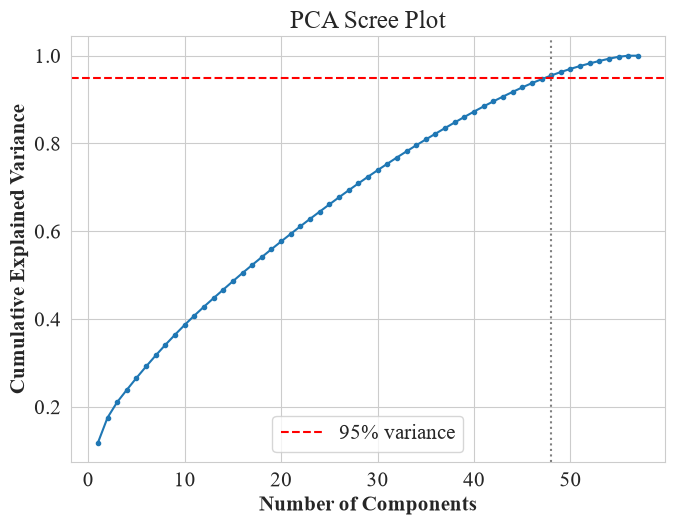

In [6]:
pca_full = PCA(random_state=RNG).fit(X_train)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components for 95% variance: {n_components_95} of {X_train.shape[1]}")

pca = PCA(n_components=n_components_95, random_state=RNG).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
explained = pca.explained_variance_ratio_.sum()
print(f"Explained variance with {n_components_95} components: {explained:.4f}")

plt.figure(figsize=(7, 5.5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker=".")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.axvline(n_components_95, color="grey", linestyle=":")
plt.xlabel("Number of Components"); plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.legend()
plt.tight_layout()
plt.savefig("figures/01_pca_scree_plot.png", dpi=150)
plt.show()
plt.close()

## Model definitions and hyperparameter grids

In [7]:
model_specs = {
    "SVM": (SVC(kernel="rbf", probability=True, random_state=RNG), {"C": [1, 10]}),
    "Naive Bayes": (GaussianNB(), {"var_smoothing": [1e-9, 1e-7]}),
    "KNN": (KNeighborsClassifier(), {"n_neighbors": [5, 11], "weights": ["uniform", "distance"]}),
    "Logistic Regression": (LogisticRegression(max_iter=2000, random_state=RNG), {"C": [0.1, 1, 10]}),
    "Decision Tree": (DecisionTreeClassifier(random_state=RNG), {"max_depth": [5, 10]}),
    "Random Forest": (RandomForestClassifier(random_state=RNG), {"n_estimators": [50, 100], "max_depth": [10, None]}),
    "AdaBoost": (AdaBoostClassifier(random_state=RNG), {"n_estimators": [50, 100]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RNG), {"n_estimators": [50, 100]}),
    "XGBoost": (XGBClassifier(device="cuda", tree_method="hist", eval_metric="logloss", random_state=RNG),
                {"n_estimators": [50, 100], "learning_rate": [0.1, 0.3]}),
    "Stacking": (StackingClassifier(
        estimators=[("svm", SVC(kernel="rbf", C=1, probability=True, random_state=RNG)),
                    ("nb", GaussianNB()),
                    ("dt", DecisionTreeClassifier(max_depth=5, random_state=RNG))],
        final_estimator=LogisticRegression(max_iter=2000, random_state=RNG), cv=5),
     {"final_estimator__C": [0.1, 1, 10]}),
}
print("Models:", list(model_specs.keys()))

Models: ['SVM', 'Naive Bayes', 'KNN', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'Stacking']


## Run every model, with and without PCA

In [8]:
results = {}
for name, (base_model, grid) in model_specs.items():
    for setting, Xtr, Xte in [("No-PCA", X_train, X_test), ("With-PCA", X_train_pca, X_test_pca)]:
        t0 = time.perf_counter()
        gs = GridSearchCV(base_model, grid, cv=cv5, scoring=["accuracy", "f1"], refit="accuracy", n_jobs=-1)
        gs.fit(Xtr, y_train)
        search_time = time.perf_counter() - t0
        run = train_and_evaluate_classifier(gs.best_estimator_, Xtr, y_train, Xte, y_test)
        cv_scores = cross_val_score(gs.best_estimator_, Xtr, y_train, cv=cv5, scoring="accuracy")
        results[(name, setting)] = dict(best_params=gs.best_params_, best_cv_acc=gs.best_score_,
                                         search_time=search_time, cv_scores=cv_scores, **run)
        print(f"{name:20s} {setting:10s} best_cv_acc={gs.best_score_:.4f} test_acc={run['metrics']['accuracy']:.4f} ({search_time:.1f}s)")

SVM                  No-PCA     best_cv_acc=0.9356 test_acc=0.9207 (3.2s)


SVM                  With-PCA   best_cv_acc=0.9332 test_acc=0.9273 (2.8s)


Naive Bayes          No-PCA     best_cv_acc=0.8149 test_acc=0.8328 (1.5s)
Naive Bayes          With-PCA   best_cv_acc=0.8046 test_acc=0.8339 (0.1s)


KNN                  No-PCA     best_cv_acc=0.9215 test_acc=0.9240 (0.3s)


KNN                  With-PCA   best_cv_acc=0.9207 test_acc=0.9218 (0.2s)


...

Gradient Boosting    With-PCA   best_cv_acc=0.9264 test_acc=0.9153 (4.7s)


XGBoost              No-PCA     best_cv_acc=0.9554 test_acc=0.9403 (6.9s)


XGBoost              With-PCA   best_cv_acc=0.9389 test_acc=0.9273 (4.6s)


Stacking             No-PCA     best_cv_acc=0.9408 test_acc=0.9294 (9.0s)


Stacking             With-PCA   best_cv_acc=0.9323 test_acc=0.9262 (6.9s)


## Comparison table

In [9]:
rows = []
for name in model_specs:
    row = {"Model": name}
    for setting in ["No-PCA", "With-PCA"]:
        r = results[(name, setting)]
        row[f"{setting} Test Acc"] = r["metrics"]["accuracy"]
        row[f"{setting} Test F1"] = r["metrics"]["f1"]
        row[f"{setting} CV Acc"] = r["cv_scores"].mean()
    rows.append(row)
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

              Model  No-PCA Test Acc  No-PCA Test F1  No-PCA CV Acc  With-PCA Test Acc  With-PCA Test F1  With-PCA CV Acc
                SVM         0.920738        0.897616       0.935598           0.927253          0.905767         0.933152
        Naive Bayes         0.832790        0.818824       0.814946           0.833876          0.812270         0.804620
                KNN         0.923996        0.903315       0.921467           0.921824          0.900000         0.920652
Logistic Regression         0.926167        0.904762       0.924457           0.929425          0.909597         0.923098
      Decision Tree         0.908795        0.882353       0.922283           0.876221          0.849604         0.887500
      Random Forest         0.942454        0.925247       0.952989           0.919653          0.896648         0.931793
           AdaBoost         0.927253        0.905767       0.935598           0.895765          0.864407         0.904620
  Gradient Boosting     

## Confusion matrices for the best model, with and without PCA

Best model by No-PCA test accuracy: Random Forest


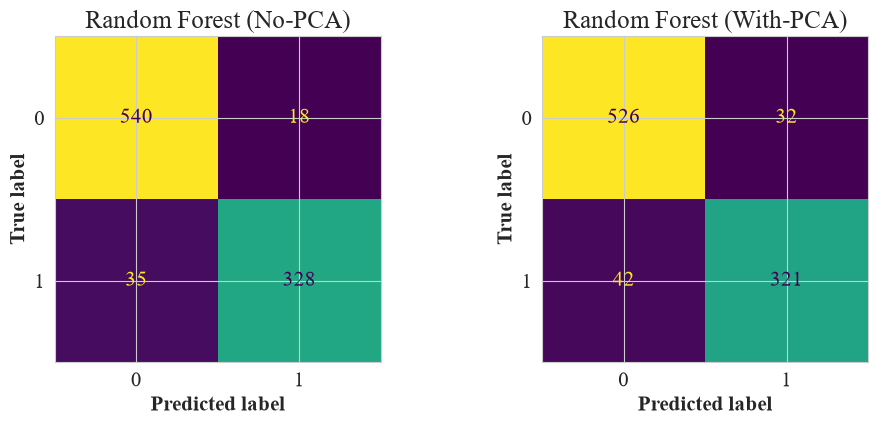

In [10]:
best_name = comparison_df.loc[comparison_df["No-PCA Test Acc"].idxmax(), "Model"]
r_no_pca = results[(best_name, "No-PCA")]
r_with_pca = results[(best_name, "With-PCA")]
print("Best model by No-PCA test accuracy:", best_name)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, r_no_pca["pred"])).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"{best_name} (No-PCA)")
ConfusionMatrixDisplay(confusion_matrix(y_test, r_with_pca["pred"])).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"{best_name} (With-PCA)")
plt.tight_layout()
plt.savefig("figures/02_confusion_matrices.png", dpi=150)
plt.show()
plt.close()

## ROC curves, with and without PCA

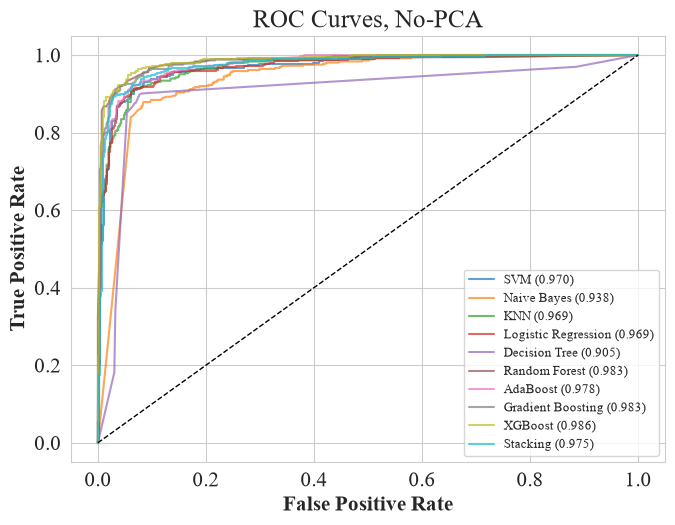

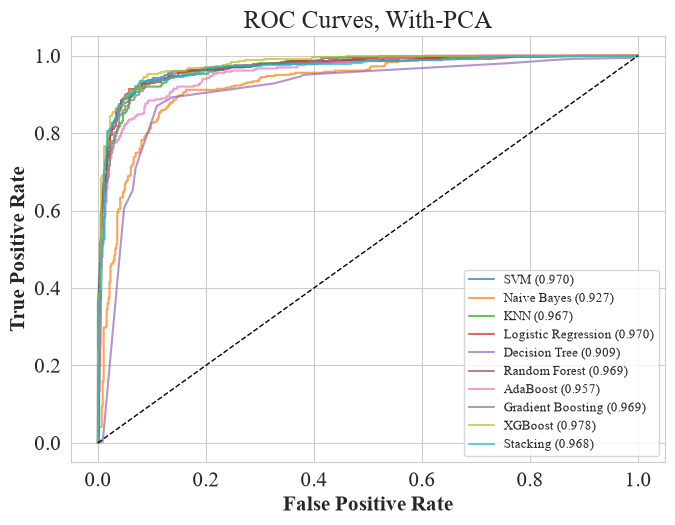

In [11]:
plt.figure(figsize=(7, 5.5))
for name in model_specs:
    r = results[(name, "No-PCA")]
    fpr, tpr, _ = roc_curve(y_test, r["score"])
    plt.plot(fpr, tpr, alpha=0.7, label=f"{name} ({roc_auc_score(y_test, r['score']):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves, No-PCA")
plt.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("figures/03_roc_curves_no_pca.png", dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(7, 5.5))
for name in model_specs:
    r = results[(name, "With-PCA")]
    fpr, tpr, _ = roc_curve(y_test, r["score"])
    plt.plot(fpr, tpr, alpha=0.7, label=f"{name} ({roc_auc_score(y_test, r['score']):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves, With-PCA")
plt.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("figures/04_roc_curves_with_pca.png", dpi=150)
plt.show()
plt.close()

## No-PCA vs With-PCA accuracy comparison

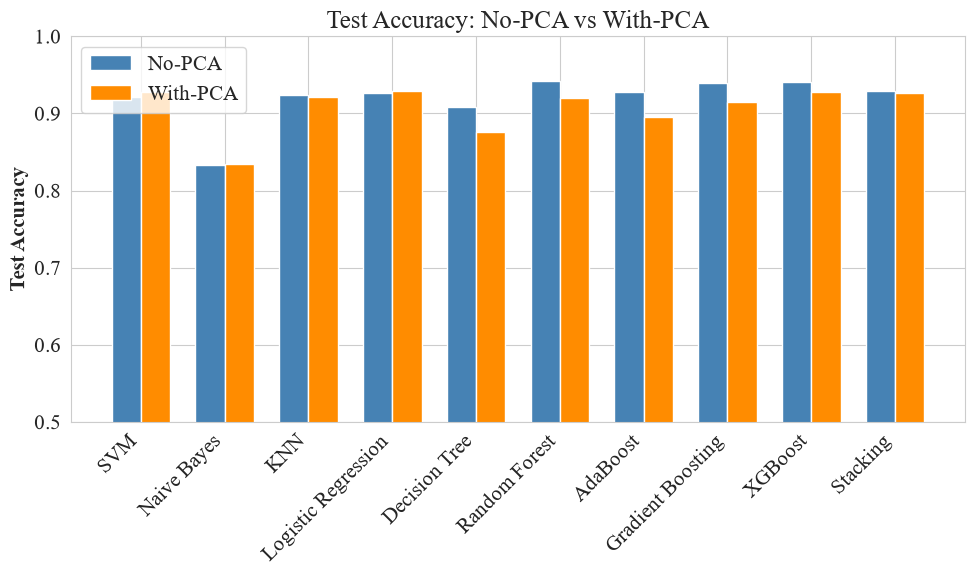

In [12]:
plt.figure(figsize=(10, 6))
x = np.arange(len(model_specs)); w = 0.35
no_pca_acc = [results[(n, "No-PCA")]["metrics"]["accuracy"] for n in model_specs]
with_pca_acc = [results[(n, "With-PCA")]["metrics"]["accuracy"] for n in model_specs]
plt.bar(x - w/2, no_pca_acc, width=w, label="No-PCA", color="steelblue")
plt.bar(x + w/2, with_pca_acc, width=w, label="With-PCA", color="darkorange")
plt.xticks(x, list(model_specs.keys()), rotation=45, ha="right")
plt.ylabel("Test Accuracy"); plt.ylim(0.5, 1.0)
plt.title("Test Accuracy: No-PCA vs With-PCA")
plt.legend()
plt.tight_layout()
plt.savefig("figures/05_pca_accuracy_comparison.png", dpi=150)
plt.show()
plt.close()

## Save results

In [13]:
comparison_df.to_csv("comparison_table.csv", index=False)

with open("results_summary.txt", "w") as f:
    f.write(f"Dataset shape: {df.shape}\n")
    f.write(f"Class distribution: {df['is_spam'].value_counts().to_dict()}\n")
    f.write(f"PCA components for 95% variance: {n_components_95} of {X_train.shape[1]}\n\n")

    for name in model_specs:
        for setting in ["No-PCA", "With-PCA"]:
            r = results[(name, setting)]
            f.write(f"{name} [{setting}] best_params={r['best_params']} best_cv_acc={r['best_cv_acc']:.4f}\n")
            f.write(f"{name} [{setting}] test_metrics={r['metrics']}\n")
            f.write(f"{name} [{setting}] 5-fold CV: {r['cv_scores'].tolist()} mean={r['cv_scores'].mean():.4f} std={r['cv_scores'].std():.4f}\n\n")

    f.write("\n=== Comparison table ===\n")
    f.write(comparison_df.to_string(index=False))

print("Done.")

Done.
